# 8. The full Arequipa DEM

Every number this project has published comes from **crops** — Colca, and small Arequipa
windows. The full DEM is the run that has never been done, and this notebook is where it
lands.

[Notebook 7](07_explaining_a_run.ipynb) covers how to drive the pipeline and how to read
what it says. This one is about one specific run, at a scale the crops cannot speak
for.

In [1]:
import json
import os

from oroscope import explain

**Read, not run.** The cells below open results that were produced locally and stored in
`results/arequipa_full/`. They do not start a search. Each of these searches takes about
half an hour, CI executes notebooks on every push, and a tutorial costing ninety minutes
of compute per commit is a bill rather than a tutorial. The expensive half runs once, on
a machine that has the DEM; the notebook opens a few hundred kilobytes of JSON.

To produce or refresh the store:

```bash
python tools/run_arequipa_full.py --dry-run   # report the cost, then stop
python tools/run_arequipa_full.py             # GRAND, TAMBO, then the combination
```

**Start with `--dry-run`.** It begins nothing — no search, no file, no change to the
store — and prints the five things worth knowing before committing an hour of a
machine:

```text
DEM:       input/dem/arequipa_SRTMGL1.tif
estimate:  5.08 GiB at downsample_factor 4
available: 6.4 GiB
would run: grand, tambo, then combine
expected:  ~25 min for grand, ~1 min for tambo
store:     results/arequipa_full
```

`DEM` says whether the file is even present, so a missing DEM is reported before the
first search starts rather than after. `estimate` against `available` is what decides
`downsample_factor` and `candidate_stride` — the same DEM needs 7.2 GiB at 1 and
5.1 GiB at 4, and downsampling helps less than it looks because the candidates are taken
on the native grid regardless. `would run` honours `--only`, so `--only grand` runs one
search and skips the combination. And no memory cap is applied during a dry run, because
nothing is allocated.

**This is a run that needs its cap set.** The default ceiling is 80% of what the system
reports available, which on a machine whose desktop already holds half of RAM is below
what the search needs: the first attempt died 23 minutes in, at the scoring stage,
against a 5.5 GiB cap. Pass `--max-memory-gb` explicitly — the run measured 5.68 GiB
peak RSS.

**Regenerate it when a configuration changes, and not otherwise.** The store carries a
manifest naming the configs and the time, so a stale one is detectable rather than
merely suspected.

Three searches, all at the same `downsample_factor` so their masks are pixel-aligned:

| | config | what it asks |
|---|---|---|
| **GRAND alone** | `config/grand_arequipa_full.json` | 3–25° deployable ground seeing a target 10–40 km away, within ±3° of the horizon |
| **TAMBO alone** | `config/tambo_arequipa_full.json` | a 20–60° near wall facing a ≥25° far wall, 2–5 km across |
| **Combined** | `combine_experiments` over both | joint, union, and how much of each sits inside the other |

**What it costs.** 10204 × 12603 pixels, about 129 Mpx. At `downsample_factor: 4` the
estimator says 5.1 GiB against the ~6–7 GiB typically free; at 1 it says 7.2 GiB, which
is why 4 is the setting. That choice has a price worth stating: area is measured on the
downsampled mask while capacity is measured at full resolution, so a feature a few
pixels wide keeps its detectors and loses area — the run puts it at around 30% for a
canyon strip. **Read these areas as lower bounds**, and more so for TAMBO's canyon
strips than for GRAND's blobs. It is the reason TAMBO's full-DEM area below cannot be
compared directly against the crop's, which was measured at `downsample_factor: 1`.

In [2]:
STORE = os.path.abspath(os.path.join("..", "results", "arequipa_full"))

def load_stored(label):
    """Reads one stored run, or returns None when the store does not have it yet."""
    path = os.path.join(STORE, f"{label}_results.json")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

manifest_path = os.path.join(STORE, "manifest.json")
if os.path.exists(manifest_path):
    with open(manifest_path) as f:
        manifest = json.load(f)
    print(f"store generated {manifest['generated']} by {manifest['generated_by']}")
    print(f"from {manifest['dem']}\n")
    for name in manifest["files"]:
        print("   ", name)
else:
    manifest = None
    print("The full-DEM store is empty: these searches have not been run yet.\n")
    print("Produce it with:")
    print("    python tools/run_arequipa_full.py --dry-run")
    print("    python tools/run_arequipa_full.py")

grand_full = load_stored("grand")
tambo_full = load_stored("tambo")

store generated 2026-08-16T07:48:37 by tools/run_arequipa_full.py
from input/dem/arequipa_SRTMGL1.tif

    combined_report.json
    grand_explanation.txt
    grand_provenance.json
    grand_results.json
    tambo_explanation.txt
    tambo_provenance.json
    tambo_results.json


### GRAND over the whole DEM

The four things worth reading, in this order:

1. **The funnel**, and specifically whether the binding constraint is the same one the
   crops found. If a full DEM is bound by a different stage than its crops were, the
   crops were not representative and every number derived from them needs re-reading.
2. **The area**, against the crop scaled up — and against the closing factor this run
   reports for itself, rather than the 2.29× quoted from Colca.
3. **The site count and their spread.** A crop cannot say whether the good ground is one
   region or fifty scattered ones, and that is a deployment question, not a physics one.
4. **The weakest score component**, which on the crops is `solid_angle` everywhere. If
   that holds at full scale it is a statement about the criterion, not about Peru.

In [3]:
def summarise(results, label):
    if results is None:
        print(f"{label}: not in the store yet.")
        return
    chosen, shortlisted = explain.selected_sites(results)
    area = sum(s["area_km2"] for s in chosen)
    binding = explain.binding_constraint(results["funnel"])
    ratio = explain.closing_inflation(results["funnel"],
                                      results["parameters"]["candidate_stride"])
    weakest = [explain.weakest_component(s.get("arrival_scan") or {}) for s in chosen]
    named = [w[0] for w in weakest if w]

    print(f"{label}")
    print(f"   sites          {results['results']['total_sites']:>10,}"
          f"   ({len(shortlisted)} more cleared the thresholds, not selected)")
    print(f"   capacity       {results['results']['total_capacity']:>10,}")
    print(f"   area           {area:>10,.1f} km²")
    if binding:
        print(f"   bound by       {binding['stage']}"
              f"  (kept {100*binding['kept_fraction']:.1f}%)")
    if ratio is not None:
        print(f"   closing moved  {ratio:>10.2f}x")
    if named:
        commonest = max(set(named), key=named.count)
        print(f"   weakest        {commonest} at {named.count(commonest)}/{len(named)} sites")

summarise(grand_full, "GRAND, full Arequipa DEM")

GRAND, full Arequipa DEM
   sites                   1   (0 more cleared the thresholds, not selected)
   capacity          101,948
   area             88,527.5 km²
   bound by       directions accepted  (kept 61.6%)
   closing moved        2.10x
   weakest        solid_angle at 1/1 sites


In [4]:
if grand_full is not None:
    print(grand_full.get("explanation") or explain.explain_results(grand_full))
else:
    print("Nothing stored for GRAND yet -- see the cell above for how to produce it.")

 WHAT THIS SEARCH FOUND, AND WHY

THE RUN
-------
  DEM              /home/mbustamante/Research/GRAND/oroscope/input/dem/arequipa_SRTMGL1.tif
  Origin           -14.555139, -73.586250  (auto-detected from the GeoTIFF tiepoint)
  Resolution       0.00027778°/px  =  30.7 m N-S x 29.7 m E-W
  Layout           distributed search, hex grid, 1.0 km spacing
  Finished         2026-08-16 07:46:53

THE HEADLINE
------------
  1 site covering 88,527.5 km², 101,948 detectors against a target of 10,000.

  Largest by capacity: site 1, 88,527.51 km², 101,948 detectors, facing S,
  centred -15.7886, -71.6611 — paste that into a map.

WHERE THE CANDIDATES WENT
-------------------------
  stage                           |         pixels |   of DEM |  of prev
  ----------------------------------------------------------------------
  DEM pixels                      |    128,601,012 | 100.000% |         -
  finite elevation                |    125,642,792 |  97.700% |  97.700%
  slope 3.0-25.0 deg       

### TAMBO over the whole DEM

The more interesting of the two, because TAMBO's criteria are canyon-shaped and the
crop was *chosen* for containing a canyon. Over the whole DEM the question becomes: how
much other canyon is there, and is any of it as good?

Note that the areas here are the ones most affected by `downsample_factor: 4`: a strip
along a wall is exactly the feature that loses area to downsampling while keeping its
detectors.

In [5]:
summarise(tambo_full, "TAMBO, full Arequipa DEM")

TAMBO, full Arequipa DEM
   sites                  26   (0 more cleared the thresholds, not selected)
   capacity            9,024
   area                111.9 km²
   bound by       directions accepted  (kept 9.7%)
   closing moved        0.52x
   weakest        solid_angle at 26/26 sites


In [6]:
if tambo_full is not None:
    print(tambo_full.get("explanation") or explain.explain_results(tambo_full))
else:
    print("Nothing stored for TAMBO yet -- see above for how to produce it.")

 WHAT THIS SEARCH FOUND, AND WHY

THE RUN
-------
  DEM              /home/mbustamante/Research/GRAND/oroscope/input/dem/arequipa_SRTMGL1.tif
  Origin           -14.555139, -73.586250  (auto-detected from the GeoTIFF tiepoint)
  Resolution       0.00027778°/px  =  30.7 m N-S x 29.7 m E-W
  Layout           distributed search, hex grid, 0.1 km spacing
  Finished         2026-08-16 07:48:32

THE HEADLINE
------------
  26 sites covering 111.9 km² between them, 9,024 detectors against a target
  of 5,000.

  Largest by capacity: site 4975, 6.55 km², 551 detectors, facing S, centred
  -15.5708, -71.9602 — paste that into a map.

WHERE THE CANDIDATES WENT
-------------------------
  stage                           |         pixels |   of DEM |  of prev
  ----------------------------------------------------------------------
  DEM pixels                      |    128,601,012 | 100.000% |         -
  finite elevation                |    125,642,792 |  97.700% |  97.700%
  slope 20.0-60.0 deg 

### Where both are viable

The overlay. On the Colca crop the answer was decided by slope: GRAND's 3–25° deployable
band against Colca's ~40° walls leaves only a 20–25° sliver, so the joint was about a
percent of GRAND's area and three fifths of TAMBO's.

Whether that survives at full scale is a real question. The crop contains one canyon
system; the DEM contains many, of varying wall slope, and the joint area is the
programme-level number — one site, one road, one power feed, two experiments.

In [7]:
report_path = os.path.join(STORE, "combined_report.json")
if not os.path.exists(report_path):
    print("The combination has not been produced yet.")
else:
    with open(report_path) as f:
        report = json.load(f)

    width = max(len(r["label"]) for r in report["runs"])
    print(f"   {'experiment'.ljust(width)} {'area km²':>12} {'sites':>7} "
          f"{'capacity':>10} {'in joint':>9}")
    print("   " + "-" * (width + 42))
    for r in report["runs"]:
        print(f"   {r['label'].ljust(width)} {r['area_km2']:>12,.1f} "
              f"{r['reported_sites']:>7,} {r['reported_capacity']:>10,} "
              f"{100*r['fraction_of_own_area_in_joint']:>8.1f}%")
    print("   " + "-" * (width + 42))
    print(f"   joint  {report['joint']['area_km2']:>10,.1f} km²")
    print(f"   union  {report['union']['area_km2']:>10,.1f} km²")
    for pair, stats in report["pairwise_overlap"].items():
        print(f"   {pair}: Jaccard {stats['jaccard']:.4f}")

   experiment     area km²   sites   capacity  in joint
   -----------------------------------------------
   GRAND     88,527.5       1    101,948      0.1%
   TAMBO        111.9      26      9,024     44.9%
   -----------------------------------------------
   joint        50.2 km²
   union    88,589.2 km²
   GRAND & TAMBO: Jaccard 0.0006


And the overlay explains itself too, the same way a search does — including the part
that is easy to get wrong. Co-location is decided by whichever *ground* property the
two experiments share least of, because a pixel has one slope and both have to accept
it. What each asks of the **view** — the distance window, the arrival elevations — may
differ freely: two experiments can look out from the same hillside at different ranges
without conflict.

`oroscope-combine` prints this and saves it as `combination_explanation.txt`.

In [8]:
if not os.path.exists(report_path):
    print("The combination has not been produced yet.")
else:
    runs = {label: res for label, res in (("GRAND", grand_full), ("TAMBO", tambo_full))
            if res is not None}
    print(explain.explain_combination(report, runs))

 WHERE THESE EXPERIMENTS CAN SHARE GROUND, AND WHY

WHAT EACH BRINGS
----------------
  experiment |     area km² |   sites |  detectors |  in joint
  ----------------------------------------------------------
  GRAND      |     88,527.5 |       1 |    101,948 |      0.1%
  TAMBO      |        111.9 |      26 |      9,024 |     44.9%

  Ground satisfying GRAND and TAMBO at once: 50.2 km². Ground useful to any
  of them: 88,589.2 km². The first is the number that matters for one site,
  one road and one power feed serving two experiments; the second is what the
  programme as a whole could use.

WHAT DECIDES IT
---------------
  A pixel has one slope, one altitude and one aspect, and both experiments
  must accept those same values to stand on it. So co-location is settled by
  whichever of those bands they share least of — before any arrival geometry
  is considered.

  band               |            GRAND |            TAMBO | shared
  -------------------------------------------------

### Comparing against the crop

The crop's numbers, for reference — GRAND 4580.2 km² in 1 site with 5317 detectors,
TAMBO 83.6 km² in 15 sites with 9717, joint 50.1 km². If the full DEM's binding
constraint or weakest component differs from these, the crop was not representative and
the comparison is the finding.

A crop is chosen because it is interesting. **A search over ground chosen for being
interesting is not a survey**, and that is the gap this run exists to close.

In [9]:
if grand_full is not None and tambo_full is not None:
    print("Both full-DEM runs are stored; compare their funnels against the crops':\n")
    for label, res in (("GRAND", grand_full), ("TAMBO", tambo_full)):
        b = explain.binding_constraint(res["funnel"])
        print(f"   {label:>6}: bound by {b['stage']!r} "
              f"(kept {100*b['kept_fraction']:.1f}%)")
    print("\n   Colca crop, for comparison:")
    print("   GRAND: bound by 'directions accepted' (kept 60.1%)")
    print("   TAMBO: bound by 'directions accepted' (kept 17.5%)")
else:
    print("Run both searches to make this comparison.")

Both full-DEM runs are stored; compare their funnels against the crops':

    GRAND: bound by 'directions accepted' (kept 61.6%)
    TAMBO: bound by 'directions accepted' (kept 9.7%)

   Colca crop, for comparison:
   GRAND: bound by 'directions accepted' (kept 60.1%)
   TAMBO: bound by 'directions accepted' (kept 17.5%)


### The maps

The store holds the numbers, not the rasters — a GeoTIFF of a 129 Mpx mask is far too
large for a repository. But the PNG maps are in `output/`, and if you have run the
searches locally they are worth looking at rather than reading about: the funnel says
*how much* ground survived, the map says *where* it is.

If `output/` is empty here, produce it with `python tools/run_arequipa_full.py`. The
images below are stored in this notebook, so they are visible either way.

In [10]:
from IPython.display import Image, display


def show_figure(path, width=1100, caption=None):
    """Displays a figure the pipeline wrote, downscaled so the notebook stays small.

    The searcher saves its map to disk and says where; a notebook that only prints the
    path makes the reader go and find it. Downscaled because the full-resolution PNG is
    a megabyte or two and these outputs are committed.
    """
    if not os.path.exists(path):
        print(f"not here yet: {os.path.relpath(path)}")
        return
    try:
        from PIL import Image as PILImage
        import io as _io
        img = PILImage.open(path)
        if img.width > width:
            img = img.resize((width, round(img.height * width / img.width)),
                             PILImage.LANCZOS)
        buf = _io.BytesIO()
        img.convert("RGB").save(buf, format="PNG", optimize=True)
        data = buf.getvalue()
        # A shaded terrain map is photographic and does not compress as PNG: the full
        # Arequipa map is 1.1 MB at this width and 190 KB as JPEG, for no visible
        # difference. Line art stays PNG, where JPEG would ring around every edge.
        if len(data) > 250 * 1024:
            jpg = _io.BytesIO()
            img.convert("RGB").save(jpg, format="JPEG", quality=82, optimize=True)
            data = jpg.getvalue()
    except Exception:                       # pillow absent: show it full size
        with open(path, "rb") as f:
            data = f.read()
    if caption:
        print(caption)
    display(Image(data=data))

GRAND over the full Arequipa DEM


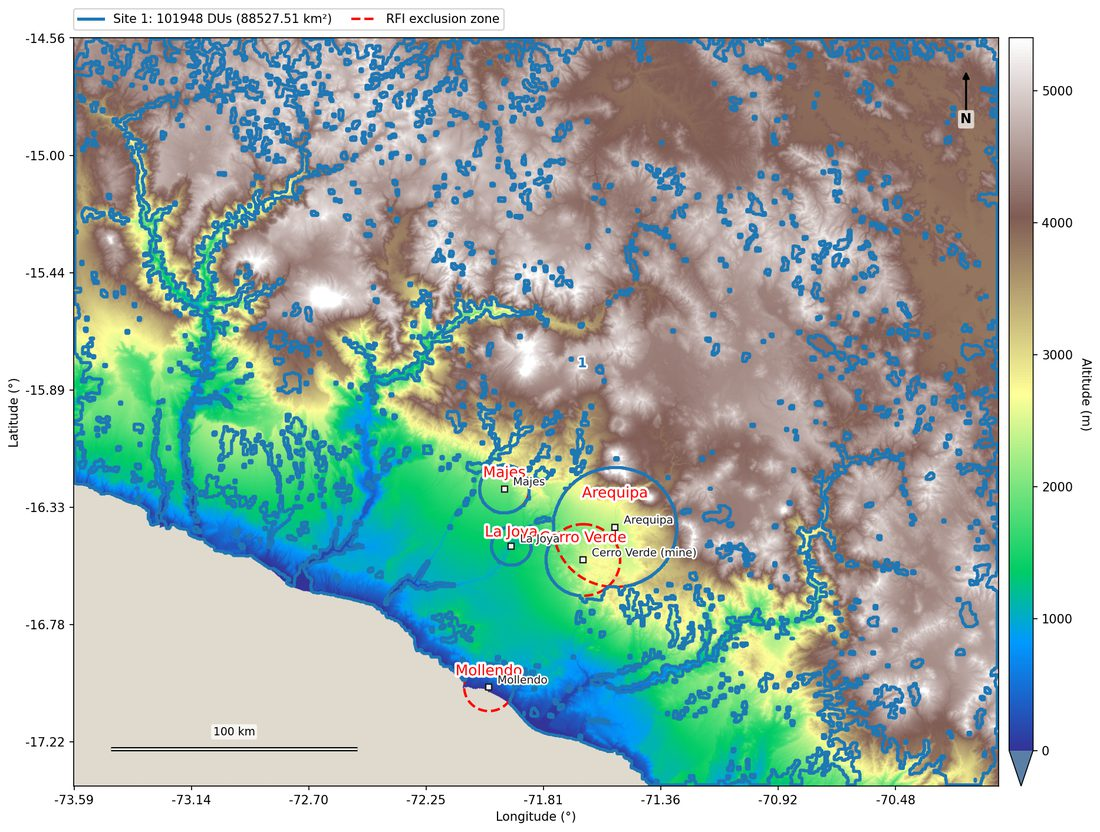

TAMBO over the full Arequipa DEM


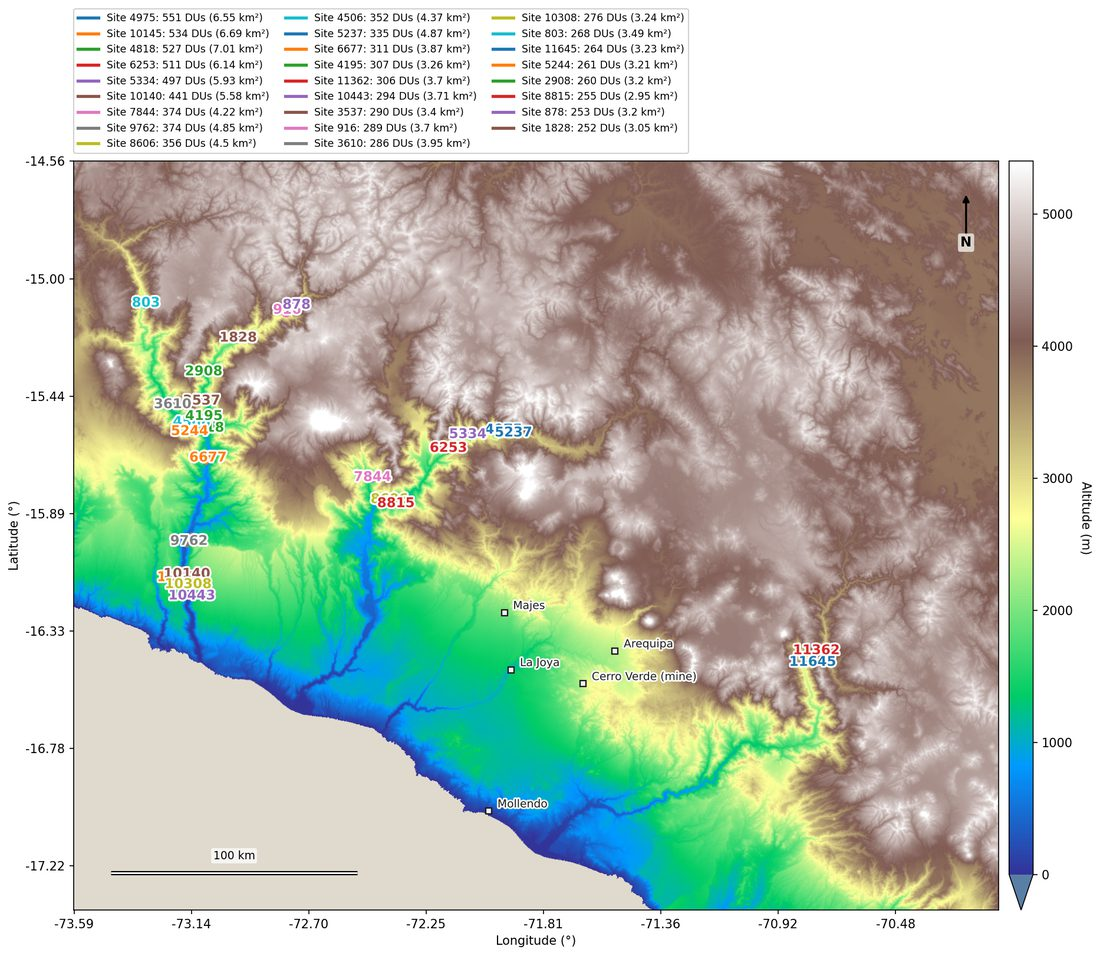

In [11]:
import glob

OUT = os.path.abspath(os.path.join("..", "output"))
for label, folder in (("GRAND", "arequipa_full_grand"),
                      ("TAMBO", "arequipa_full_tambo")):
    found = sorted(glob.glob(os.path.join(OUT, folder, "oroscope_results*.png")))
    show_figure(found[0] if found else os.path.join(OUT, folder, "none.png"),
                caption=f"{label} over the full Arequipa DEM")

And the overlay, which is the one worth dwelling on. Altitude is greyscale so the
three categories are the only colours on the map; GRAND is outlined rather than filled
because it covers most of the frame, and a wash over that much of a map hides
everything underneath it. The magenta is the 50.2 km² both experiments accept.

GRAND and TAMBO overlaid, with the co-located ground in magenta


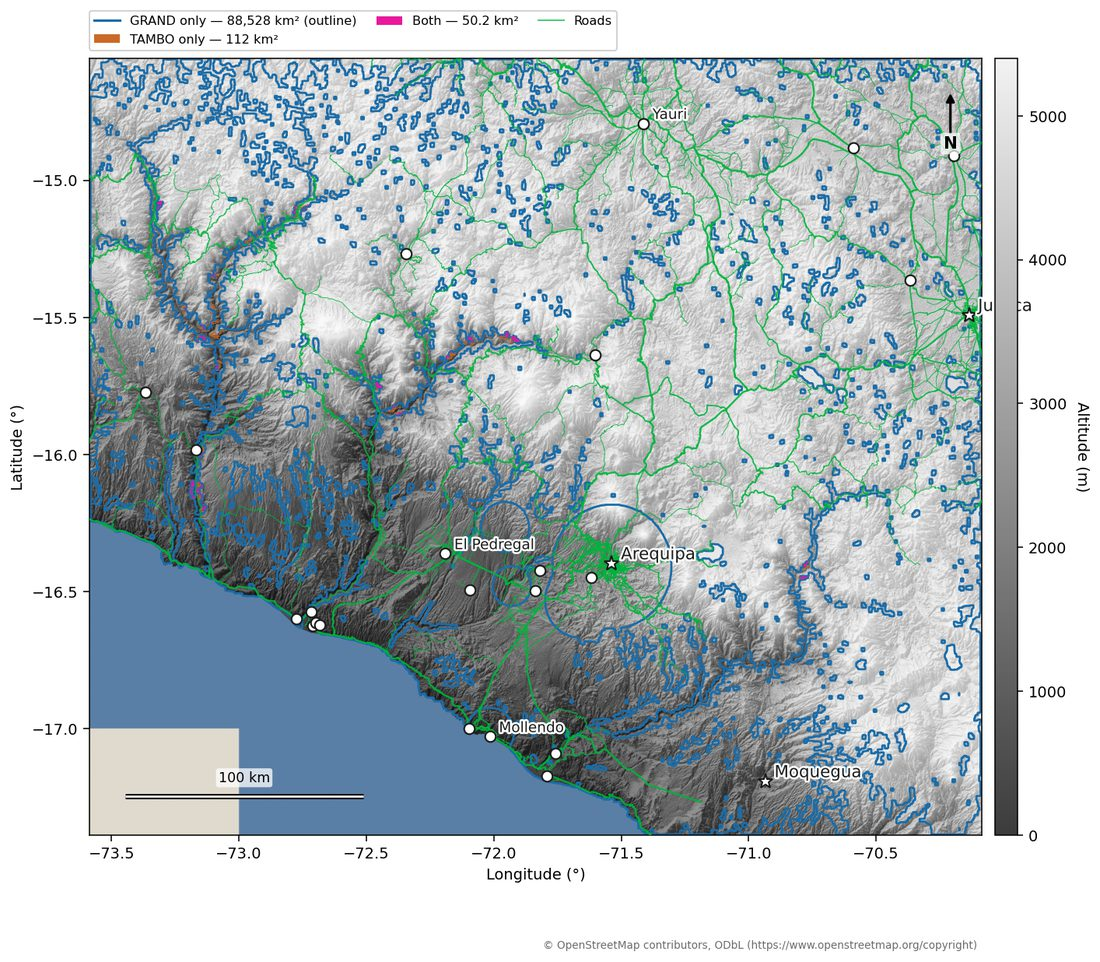

In [12]:
found = sorted(glob.glob(os.path.join(OUT, "arequipa_full_combined", "*.png")))
show_figure(found[0] if found else os.path.join(OUT, "arequipa_full_combined", "none.png"),
            caption="GRAND and TAMBO overlaid, with the co-located ground in magenta")

## Every assumption behind these numbers

A search produces authoritative-looking areas and detector counts, and the only defence
against those being over-read is writing down what is behind them. This is the complete
list for *this* run — not a generic one. Where an effect has been measured, the measured
size is given; where it has not, that is said instead.

The run says most of this about itself: `explanation.txt` carries a
**WHICH OF THESE ARE ASSUMPTIONS** block, and the cell below prints it. What follows adds
the ones that live in the configuration rather than the pipeline, and the ones measured
after the run.

In [13]:
for label, res in (("GRAND", grand_full), ("TAMBO", tambo_full)):
    if res is None:
        continue
    text = res.get("explanation") or explain.explain_results(res)
    block = text.split("WHICH OF THESE ARE ASSUMPTIONS")
    if len(block) > 1:
        print(f"===== {label} =====")
        print("WHICH OF THESE ARE ASSUMPTIONS" + block[1].split("WHAT TO TRY NEXT")[0])

===== GRAND =====
WHICH OF THESE ARE ASSUMPTIONS
------------------------------
  Choices, not measurements. Check them before quoting a result.

  • geomag_declination_deg = -6.9°
      Constant across the DEM unless a declination model was supplied — the
      centred dipole that gives inclination is unreliable for declination
      (-0.2° against a measured -6.9° at Arequipa), so it falls back to
      Arequipa's IGRF value. Right for southern Peru, wrong elsewhere.
      physics.set_declination_model() takes any callable, and
      declination_from_grid() builds one from a NOAA export.
  • max_range_km = unset
      Column depth accumulates over the whole profile walk, which then stops
      at max_dist_km — so the reported depth is a property of where the walk
      stopped, not of the target's thickness. Measured on TAMBO at Colca:
      walking to 20 km instead of the 5 km distance window raised the
      reported depth 6.4× and changed the selection not at all. Read this
      

### 1. Choices written into the configuration

Both configs mark these `ASSUMPTION` in their own comments. They are the numbers a
collaboration should be asked about before any of this is quoted.

| | value | what it rests on |
|---|---|---|
| **`solid_angle_half_sr`** (TAMBO) | 0.8 sr | The scale at which accepted sky stops being scarce. The default 0.05 is GRAND-scale and saturates the term to ~1 across a canyon, so it stops discriminating. **This is what the TAMBO result actually turns on** — `solid_angle` is the weakest component at 26 of 26 sites. |
| **`min_score`** (TAMBO) | 0.35 | A cut on a *product* of components, whose distribution piles up near zero. Equivalent to `score_percentile` **22.8** on this terrain, and a scan across the cut shows **no knee** — area runs 3.1 → 186.8 km² across percentiles 5 → 40, smooth and near linear. Nothing marks 0.35 as natural. |
| **near-wall band** (TAMBO) | 20–60° | The wall the array stands on. Colca's walls are ~40°, far outside GRAND's 3–25°. |
| **`min_target_slope_deg`** (TAMBO) | 25° | The far wall the tau exits, measured along the arrival azimuth. Deliberately permissive against ~40° walls. Without it the scan only asks that rock is present at the right range, which is true almost everywhere in the Andes. |
| **arrival window** (TAMBO) | ±20° | What the far wall subtends from a detector on the near wall. |
| **`grammage_band_gcm2`** (TAMBO) | 236–1287 | = `grammage_band_from_energy(3, 1000, fraction=0.1)`. The 0.1 is a choice about detector capability — how far down the profile still counts as a usable shower — not a property of the shower. |
| **`decay_spectral_index`** (TAMBO) | 2.0 | The flux slope the decay term folds against. The canonical value. Costs 1.46× across a plausible range; may be given as a `(low, high)` pair to marginalise instead of choosing. |
| **arrival window** (GRAND) | ±3° | The Earth-skimming geometry. Note the ±3° window sits *below* the horizon almost everywhere: the median horizon is +7.3°. |
| **distance window** (GRAND) | 10–40 km | Far enough for the shower to develop, close enough for the signal. |

### 2. Choices forced by running at full scale

These are not physics. They are the price of searching 128.6 Mpx on one machine, and
each one moves a reported number.

| | value | what it costs |
|---|---|---|
| **`downsample_factor`** | 4 | Area is measured on the downsampled mask while capacity is measured at full resolution, so a feature a few pixels wide keeps its detectors and loses area — **~30% for a canyon strip**. Affects TAMBO far more than GRAND. |
| **`candidate_stride`** | 5 | Unbiased in *acceptance* — 17.494% against 17.491% at stride 1 — but the mask is closed before area is taken, and a 100 m element cannot bridge the 154 m gap stride 5 leaves. **TAMBO's area is 4.75× low** because of this. GRAND's 1 km element is unaffected. |
| **`gap_close_km`** | = detector spacing | Closing inflates GRAND's area **2.10×** in this run (2.29× measured against a stride-1 control). Reported area is not physics-accepted area. |
| **`max_range_km`** | unset | The profile walk stops at `max_dist_km`, so the reported **column depth is a property of where the walk stopped**. Measured on TAMBO: walking 4× further raised it **6.4×** with an identical selection. Read the depths as lower bounds. |
| **`min_width_km`** | 2.0 GRAND / 0.0 TAMBO | The opening step prunes tendrils. At GRAND's 2 km it would delete exactly the strip a canyon array is, which is why TAMBO sets it to 0. |

### 3. Physics not modelled at all

| | |
|---|---|
| **Detector acceptance `A(E)`** | An event rate is ∫Φ·A·P dE. `decay_weight_by` now selects flux, acceptance, or both — **these numbers used `flux`**. No real differential table exists; one inferred from a published curve is not a safe substitute. |
| **Tau production and escape through rock** | Not modelled, so β does not enter. The search weights by the decay length E/m·cτ, which is kinematics. |
| **Neutral-current regeneration** | Available (`nc_regeneration=True`) but **off here**, so Earth-chord suppression is overstated — by 1.06× at −0.5° rising to 1.56× at −5°. |
| **Shower simulation, detector response, trigger** | None of it. The scores rank sites; they are not apertures. |
| **Geology** | One standard rock density throughout. |
| **Geomagnetic declination** | Constant at Arequipa's −6.9° across the whole DEM. Inclination does follow the site. Right for southern Peru, and this DEM is southern Peru. |
| **External validation** | **Nothing here has been checked against an external simulation.** The Earth-absorption prediction — the window's lower edge climbing from −4.4° at 100 PeV to −0.9° at 10 EeV — is the cheapest such test and is ready for someone to run. |

### 4. And the one that is not an assumption at all

The layout is **anchored, not fitted**: detectors are placed from each site's bounding-box
corner rather than optimised. Capacity is an estimate for an arbitrarily placed array, and
a real deployment would do better.

---

**If you quote one number from this notebook, quote it with its caveat.** GRAND's
88,527.5 km² is a closed mask, 2.10× the accepted set. TAMBO's 111.9 km² is low by ~4.75×
from striding and ~30% again from downsampling. The joint 50.2 km² inherits both, and is
a floor rather than an estimate.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [Combining and sensitivity](06_combining_and_sensitivity.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*